# Telco Customer Churn Prediction

**Predict which customers are about to leave - before they leave.**

Author: **MD. Sakib Al Hasan** — Data Science Portfolio Project

Goal: binary classification on the IBM Telco Customer Churn dataset (7043 customers, 21 columns) to predict `Churn` from account, service and billing information. This notebook follows the full end-to-end ML workflow: loading, inspection, EDA, cleaning, feature engineering, modeling, tuning, evaluation and saving.

## Step 1 — Problem Understanding

- **Task:** Binary classification (Supervised). Predict `Churn` = Yes/No.
- **Who has this problem:** telecommunications providers. Every churner costs the company recurring revenue; acquiring a new customer is far more expensive than retaining an existing one. If we can flag at-risk customers early, retention teams can act before the cancellation happens.
- **Success metric:** the classes are imbalanced (about 73% stay / 27% churn), so raw accuracy alone is misleading. We'll judge models on **ROC-AUC** and **F1**, plus precision/recall on the Yes (churn) class.
- **Research question: can we determine, from a customer's service/account/billing profile, which customers are likely to churn, and what could be done about it?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print('setup ok')

setup ok


## Step 2 — Data Loading

Source: [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (same file distributed on IBM's sample-data repo). **7043 rows x 21 columns.** One row per customer; the period looks like the company's records at a single point in time (mix of new and long-tenured customers).

In [2]:
DATA_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)

Shape: (7043, 21)


## Step 3 — Initial Inspection

Quick look at head / tail / sample and column types.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
len(df), len(df.columns)

(7043, 21)

## Step 4 — Column Understanding

Every column classified:

| Role | Columns |
|---|---|
| **ID** (drop from model) | `customerID` |
| **Target** | `Churn` |
| **Numeric features** | `tenure`, `MonthlyCharges`, `TotalCharges` (stored as text — fix needed), `SeniorCitizen` (0/1) |
| **Categorical features** | `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod` |

The categorical columns that describe internet add-ons (`OnlineSecurity`, `TechSupport`, ...) carry a special `No phone service` / `No internet service` level that is NOT a missing value — it means "doesn't have that service". So no imputation for those.

## Step 5 — Target Identification

`Churn` is the target. 26.5% of customers churned — clearly imbalanced.

In [5]:
target = 'Churn'
y = df[target]
X = df.drop(columns=[target, 'customerID'])
print(y.value_counts())
print('\nShares:')
print(y.value_counts(normalize=True).round(4) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Shares:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


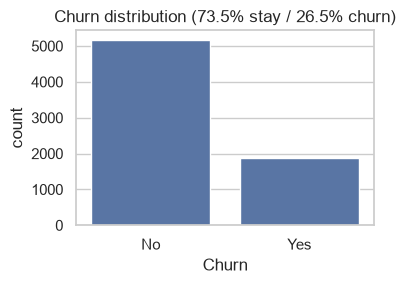

In [6]:
fig, ax = plt.subplots(figsize=(4,3))
sns.countplot(x=y, ax=ax)
ax.set_title('Churn distribution (73.5% stay / 26.5% churn)')
plt.tight_layout(); plt.show()

## Step 6 — Data Types Check

Two problems visible already: `TotalCharges` is `object` (should be numeric), everything else looks sensible.

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## Step 7 — Missing Value Handling

No `NaN`s anywhere — but `TotalCharges` has **11 blank strings**. Those 11 rows all have `tenure = 0` (brand new customers) which means they haven't accumulated any charges yet, so blank = 0 there, not a data error. We'll clean this in Step 16.

In [8]:
print('NaN per column:')
print(df.isnull().sum().sum(), 'total NaNs')
print()
blanks = (df['TotalCharges'].astype(str).str.strip() == '')
print('TotalCharges blank strings:', blanks.sum())
print('tenure values on those rows:', df.loc[blanks, 'tenure'].unique())
print('MonthlyCharges on those rows:', df.loc[blanks, 'MonthlyCharges'].describe().round(2).to_dict())

NaN per column:
0 total NaNs

TotalCharges blank strings: 11
tenure values on those rows: [0]
MonthlyCharges on those rows: {'count': 11.0, 'mean': 41.42, 'std': 23.83, 'min': 19.7, '25%': 20.12, '50%': 25.75, '75%': 58.97, 'max': 80.85}


## Step 8 — Duplicate Check

No fully duplicated rows.

In [9]:
print('Duplicated rows:', df.duplicated().sum())

Duplicated rows: 0


## Step 9 — Unique Value Check

`gender`, `Partner`, `Dependents` etc. are clean binary categories; `InternetService`, `Contract`, `PaymentMethod` have more levels. No stray/misspelled categories.

In [10]:
df.nunique().to_frame('n_unique')

,n_unique
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [11]:
for col in df.select_dtypes(include='object').columns:
    print(col, '->', df[col].unique()[:8])

customerID -> <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC']
Length: 8, dtype: str
gender -> <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines -> <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService -> <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup -> <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport -> <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV -> <StringArray>
['No', 'Yes', 'No i

## Step 10 — Basic Statistics

Median tenure is 29 months, median monthly charge ~$80, mean total charge ~$2,283. The distributions are right-skewed, so medians tell the story better than means.

In [12]:
df.drop(columns=['customerID']).describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


## Step 11 — Univariate EDA

- `MonthlyCharges` is bimodal (fibre users pay much more).
- `tenure` has a spike at 0 (new customers) and otherwise spreads out — strong predictor of churn.
- Most category counts are heavily one-sided (e.g. only ~16% senior citizens, ~10% churn among one-year contracts... we'll verify that in bivariate).

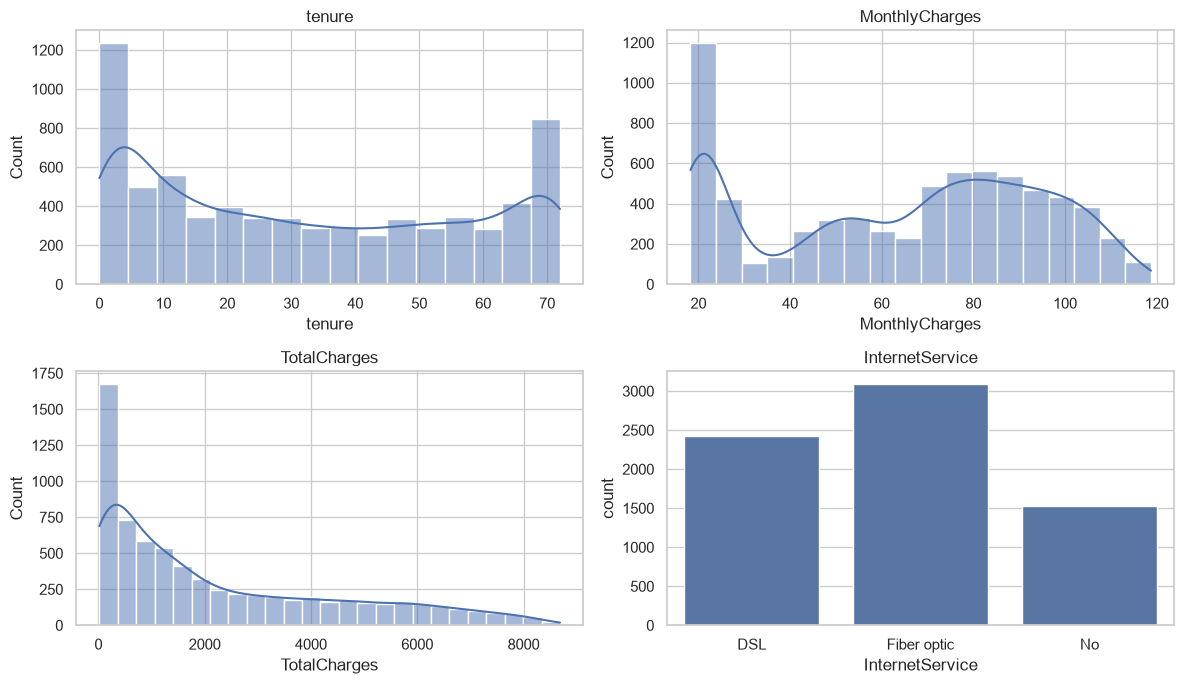

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sns.histplot(df['tenure'], kde=True, ax=axes[0,0])
axes[0,0].set_title('tenure')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0,1])
axes[0,1].set_title('MonthlyCharges')
sns.histplot(pd.to_numeric(df['TotalCharges'], errors='coerce'), kde=True, ax=axes[1,0])
axes[1,0].set_title('TotalCharges')
sns.countplot(x='InternetService', data=df, ax=axes[1,1])
axes[1,1].set_title('InternetService')
plt.tight_layout(); plt.show()

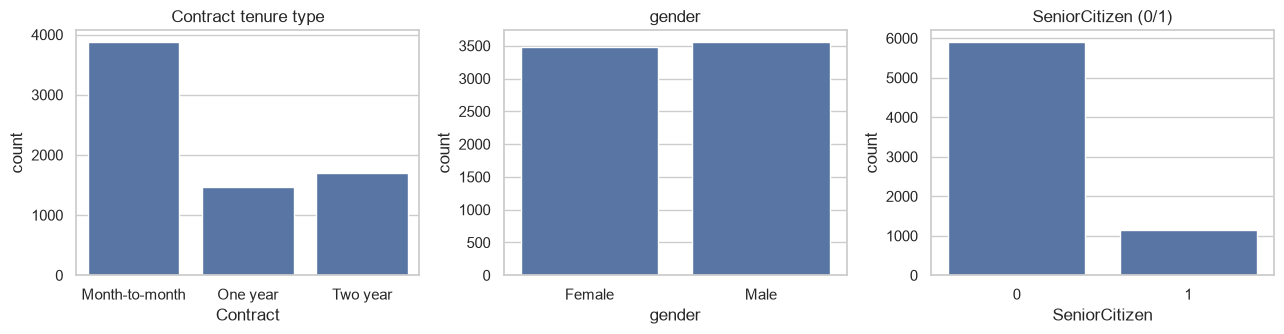

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
sns.countplot(x='Contract', order=['Month-to-month','One year','Two year'], data=df, ax=axes[0])
axes[0].set_title('Contract tenure type')
sns.countplot(x='gender', data=df, ax=axes[1])
axes[1].set_title('gender')
sns.countplot(x='SeniorCitizen', data=df, ax=axes[2])
axes[2].set_title('SeniorCitizen (0/1)')
plt.tight_layout(); plt.show()

## Step 12 — Bivariate EDA

The interesting patterns:

- **Churners are heavily concentrated in month-to-month contracts** — ~89% of churners vs 47% of stayers are on the rolling contract.
- **Fiber optic internet churns worst** despite being the premium product.
- **Churners have much shorter tenure** (median ~10 months vs ~38 for stayers) and pay slightly higher monthly charges.
- **Electronic check payment churns way more than auto-pay** — recurring-payment customers (auto bank transfer/credit card) overwhelmingly stay.

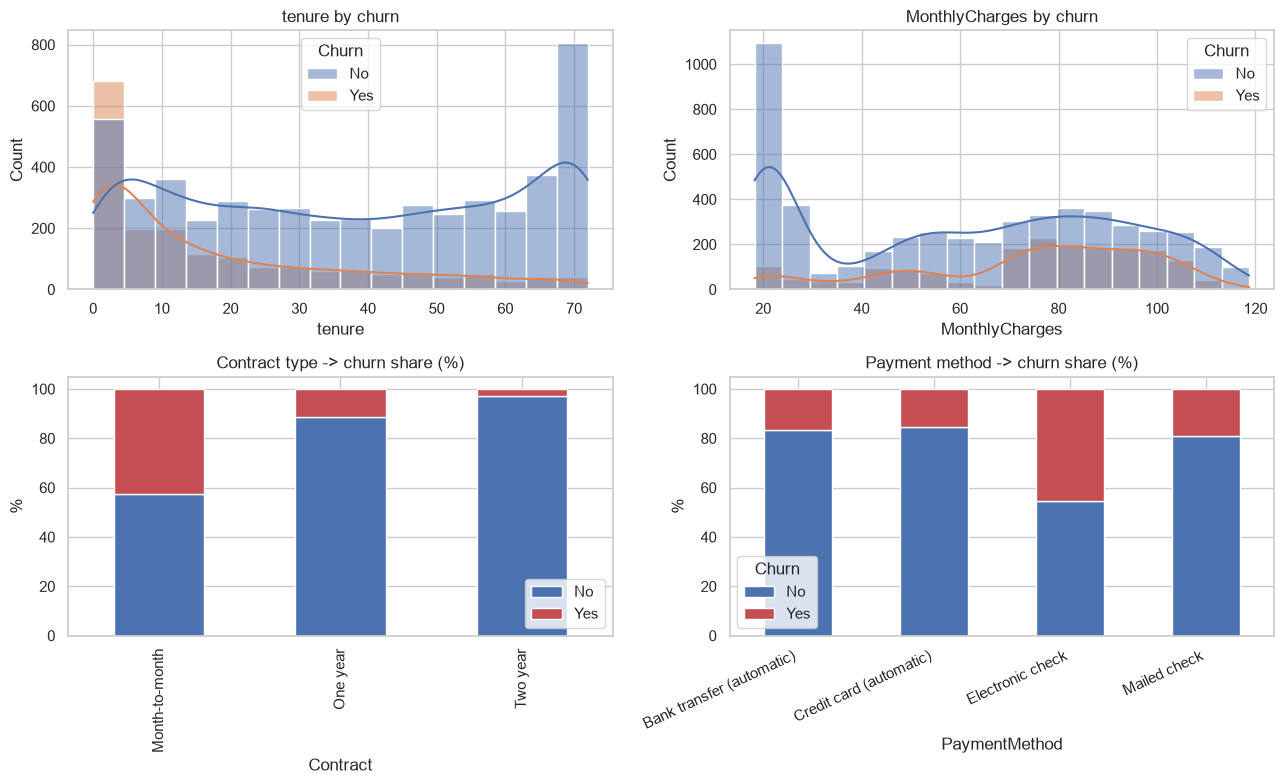

In [15]:
df2 = df.copy()
df2['TotalCharges_num'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(data=df2, x='tenure', hue='Churn', kde=True, ax=axes[0,0])
axes[0,0].set_title('tenure by churn')
sns.histplot(data=df2, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0,1])
axes[0,1].set_title('MonthlyCharges by churn')

ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct = ct[['No','Yes']].reindex(['Month-to-month','One year','Two year'])
ct.plot(kind='bar', stacked=True, ax=axes[1,0], color=['#4C72B0','#C44E52'])
axes[1,0].set_title('Contract type -> churn share (%)')
axes[1,0].set_ylabel('%')
axes[1,0].legend(loc='lower right')

cm = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
cm = cm[['No','Yes']]
cm.plot(kind='bar', stacked=True, ax=axes[1,1], color=['#4C72B0','#C44E52'])
axes[1,1].set_title('Payment method -> churn share (%)')
axes[1,1].set_ylabel('%')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=25, ha='right')
plt.tight_layout(); plt.show()

In [16]:
ct_inet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print('Churn share by InternetService:')
print(ct_inet[['Yes']].round(1))

print('\nMedian tenure (months):')
print(df.groupby('Churn')['tenure'].median())

print('\nMedian MonthlyCharges:')
print(df.groupby('Churn')['MonthlyCharges'].median())

Churn share by InternetService:
Churn             Yes
InternetService      
DSL              19.0
Fiber optic      41.9
No                7.4

Median tenure (months):
Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

Median MonthlyCharges:
Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64


## Step 13 — Multivariate EDA

Numeric correlation is small overall; the strongest relationship is between `MonthlyCharges`/`TotalCharges` (built-in relationship) and tenure/TotalCharges (accumulated charges). Churn signals live mostly in the categorical contracts/payment patterns rather than in numeric correlation.

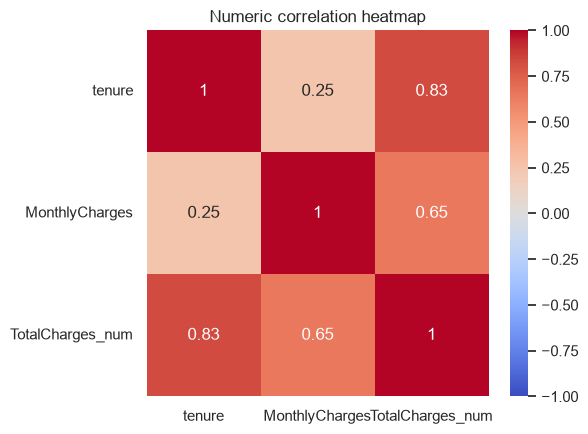

In [17]:
numcols = ['tenure', 'MonthlyCharges', 'TotalCharges_num']
plt.figure(figsize=(6,4.5))
sns.heatmap(df2[numcols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Numeric correlation heatmap')
plt.tight_layout(); plt.show()

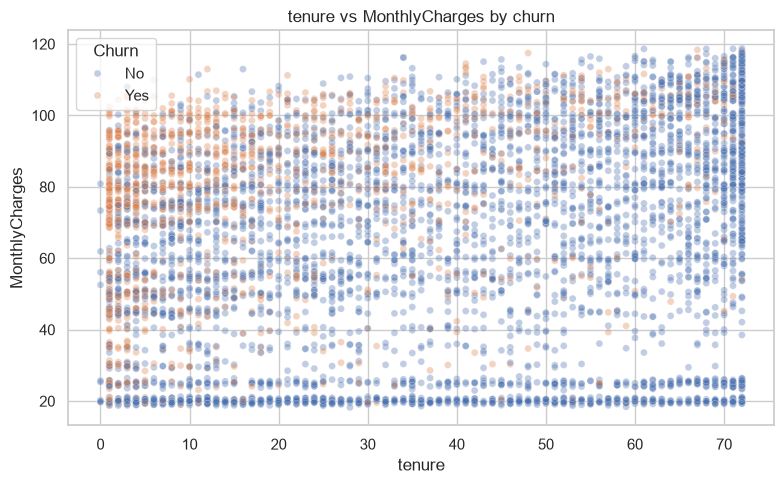

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df2, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.35, s=25)
plt.title('tenure vs MonthlyCharges by churn')
plt.tight_layout(); plt.show()

## Step 14 — Outlier Detection

IQR check on the three numeric columns. No genuine outliers — telecom billing has wide but legitimate ranges (heavy users rightfully pay a lot). Skewness is mild everywhere (all |skew| < 1), so no transformation, no winsorizing: there's real signal in those extremes.

In [19]:
from scipy import stats
for col in numcols:
    s = df2[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lb) | (s > ub)).sum()
    print(f'{col:18s} skew={stats.skew(s):6.2f}  IQR outliers={n_out:4d}  ({(n_out/len(s))*100:.1f}%)')

tenure             skew=  0.24  IQR outliers=   0  (0.0%)
MonthlyCharges     skew= -0.22  IQR outliers=   0  (0.0%)
TotalCharges_num   skew=  0.96  IQR outliers=   0  (0.0%)


## Step 15 — Correlation & Multicollinearity

VIF on the numeric features: `TotalCharges` is collinear with `tenure` (VIF > 10) since it's essentially a running total of monthly bills. This matters for linear models but tree/boosting models handle it fine. Decision: keep tenure and MonthlyCharges as the primary numeric inputs; keep TotalCharges too for the comparison because gradient boosting handles correlated features gracefully — and drop-check at the end.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
Xnum = df2[numcols].dropna()
vif = pd.DataFrame({'feature': Xnum.columns,
                    'VIF': [variance_inflation_factor(Xnum.values, i) for i in range(Xnum.shape[1])]})
vif.round(2)

,feature,VIF
0,tenure,5.84
1,MonthlyCharges,3.23
2,TotalCharges_num,9.53


In [21]:
# quick sanity: how much does dropping TotalCharges hurt a logistic baseline?
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Xt = Xnum.copy(); Xt['y'] = le.fit_transform(df2.loc[Xnum.index, 'Churn'])
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
for cols in [['tenure','MonthlyCharges'], ['tenure','MonthlyCharges','TotalCharges_num']]:
    sc = cross_val_score(LogisticRegression(max_iter=1000), Xt[cols], Xt['y'], cv=5, scoring='roc_auc')
    print(cols, '-> AUC', round(sc.mean(), 4))

['tenure', 'MonthlyCharges'] -> AUC 0.8076


['tenure', 'MonthlyCharges', 'TotalCharges_num'] -> AUC 0.8085


## Step 16 — Data Cleaning

- Drop `customerID` (done in Step 5 — it's an ID, not a feature).
- Convert `TotalCharges` to numeric; the 11 blanks (tenure=0, new customers) get filled with 0.
- Tidy categorical values (strip whitespace / consistent case) — they were already clean here.

In [22]:
X_clean = X.copy()
X_clean['TotalCharges'] = pd.to_numeric(X_clean['TotalCharges'], errors='coerce')
X_clean['TotalCharges'] = X_clean['TotalCharges'].fillna(0.0).astype(float)
print('TotalCharges dtype after cleaning:', X_clean['TotalCharges'].dtype)
print('Remaining NaNs after cleaning:', X_clean.isnull().sum().sum())
print('TotalCharges min (should be 0):', X_clean['TotalCharges'].min())

TotalCharges dtype after cleaning: float64
Remaining NaNs after cleaning: 0
TotalCharges min (should be 0): 0.0


## Step 17 — Feature Engineering

Two small hand-built features to capture engagement and payment habits:

- `ServiceCount` — how many internet add-ons a customer subscribes to (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies = Yes). More engaged = less likely to churn.
- `AutoPay` — 1 if payment is handled automatically (bank transfer / credit card automatic), else 0. Auto-pay strongly tracks retention.

In [23]:
addon_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
X_clean['ServiceCount'] = (X_clean[addon_cols] == 'Yes').sum(axis=1)
X_clean['AutoPay'] = X_clean['PaymentMethod'].isin(['Bank transfer (automatic)','Credit card (automatic)']).astype(int)
print(X_clean[['ServiceCount','AutoPay']].describe())
print('\nChurn rate by AutoPay:')
print(pd.crosstab(X_clean['AutoPay'], y, normalize='index')['Yes'].round(3) * 100)

       ServiceCount      AutoPay
count   7043.000000  7043.000000
mean       2.037910     0.435326
std        1.847682     0.495835
min        0.000000     0.000000
25%        0.000000     0.000000
50%        2.000000     0.000000
75%        3.000000     1.000000
max        6.000000     1.000000

Churn rate by AutoPay:
AutoPay
0    34.7
1    16.0
Name: Yes, dtype: float64


In [24]:
print('Churn rate by ServiceCount (0..6 add-ons):')
print((pd.crosstab(X_clean['ServiceCount'], y, normalize='index')['Yes'] * 100).round(1))

Churn rate by ServiceCount (0..6 add-ons):
ServiceCount
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Yes, dtype: float64


## Step 18 — Feature Selection

~21 informative features total (customerID already dropped). Rather than aggressively shrinking the feature set (tree ensembles do their own feature selection internally), we use a filter check (`SelectKBest` / mutual information) as a sanity test and rely on the model's native feature importances for the final story.

In [25]:
# filter-method sanity check on the numeric + engineered features
skb_df = pd.DataFrame({'feature': X_clean.columns, 'type': X_clean.dtypes.astype(str)})
print(skb_df.head(25).to_string(index=False))

         feature    type
          gender     str
   SeniorCitizen   int64
         Partner     str
      Dependents     str
          tenure   int64
    PhoneService     str
   MultipleLines     str
 InternetService     str
  OnlineSecurity     str
    OnlineBackup     str
DeviceProtection     str
     TechSupport     str
     StreamingTV     str
 StreamingMovies     str
        Contract     str
PaperlessBilling     str
   PaymentMethod     str
  MonthlyCharges float64
    TotalCharges float64
    ServiceCount   int64
         AutoPay   int64


In [26]:
# mutual information (fast filter) on a one-hot copy, just to rank raw signal
Xo = pd.get_dummies(X_clean, drop_first=True)
from sklearn.feature_selection import SelectKBest, mutual_info_classif
mi = mutual_info_classif(Xo, (y == 'Yes').astype(int).values, random_state=42)
top_mi = pd.Series(mi, index=Xo.columns).sort_values(ascending=False).head(12)
print('Top info features (mutual information):')
print(top_mi.round(4).to_string())

Top info features (mutual information):
tenure                                 0.0724
Contract_Two year                      0.0621
MonthlyCharges                         0.0537
PaymentMethod_Electronic check         0.0513
InternetService_Fiber optic            0.0507
TotalCharges                           0.0445
OnlineBackup_No internet service       0.0389
StreamingTV_No internet service        0.0371
StreamingMovies_No internet service    0.0367
InternetService_No                     0.0322
OnlineSecurity_No internet service     0.0322
ServiceCount                           0.0265


## Step 19 — Encoding & Step 20 — Scaling

Both are *inside* the final pipeline (via `ColumnTransformer`) so we never leak anything between train/test:
- Numeric columns → `StandardScaler`
- Categorical columns → `OneHotEncoder(handle_unknown='ignore')`

`SeniorCitizen` is kept as categorical (two levels: 0/1).

In [27]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AutoPay']
categorical_cols = [c for c in X_clean.columns if c not in numeric_cols]
print('numeric:', numeric_cols)
print('categorical:', categorical_cols)

numeric: ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AutoPay']
categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

## Step 21 — Train / Validation / Test Split (leakage-safe)

70% train, 15% validation (model selection / tuning), 15% test (used ONCE at the very end). Stratified on `Churn` so the imbalance ratio is preserved in every split.

In [29]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, (y == 'Yes').astype(int), test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('train:', X_train.shape, y_train.value_counts(normalize=True).round(3).to_dict())
print('val  :', X_val.shape, y_val.value_counts(normalize=True).round(3).to_dict())
print('test :', X_test.shape, y_test.value_counts(normalize=True).round(3).to_dict())

train: (4930, 21) {0: 0.735, 1: 0.265}
val  : (1056, 21) {0: 0.735, 1: 0.265}
test : (1057, 21) {0: 0.734, 1: 0.266}


## Step 22 — Class Imbalance Handling

Train set is 73/27 (No/Yes). We try **SMOTE** (synthetic oversampling of the churn class) inside an `imblearn.Pipeline`, so oversampling only ever happens on the training folds during cross-validation — never on validation/test. This is the leakage-safe way to use SMOTE.

We'll demo SMOTE's effect on the training distribution, then let the pipeline handle it per-fold.

In [30]:
print('Before SMOTE (train):')
print(y_train.value_counts())

X_train_enc = preprocessor.fit_transform(X_train)
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_enc, y_train)
print('\nAfter SMOTE (train):')
print(pd.Series(y_sm).value_counts())

Before SMOTE (train):
Churn
0    3622
1    1308
Name: count, dtype: int64



After SMOTE (train):
Churn
0    3622
1    3622
Name: count, dtype: int64


In [31]:
def make_pipeline(model, use_smote=True):
    steps = [('preprocess', preprocessor)]
    if use_smote:
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('model', model))
    return ImbPipeline(steps)

## Step 23 — Baseline Model

Logistic Regression (with SMOTE, `class_weight` left default since SMOTE already balances) as the dumb-simple baseline. 5-fold CV on train scores ~0.83 ROC-AUC / 0.57 F1.

In [32]:
base = make_pipeline(LogisticRegression(max_iter=1000))
for scoring in ['roc_auc', 'f1', 'accuracy']:
    sc = cross_val_score(base, X_train, y_train, cv=5, scoring=scoring)
    print(f'{scoring:9s}: {sc.mean():.4f} (+/- {sc.std():.4f})')

roc_auc  : 0.8454 (+/- 0.0123)


f1       : 0.6354 (+/- 0.0189)


accuracy : 0.7550 (+/- 0.0169)


## Step 24 → 25 — Model Comparison (Cross-Validation)

Six models, all wrapped in the same SMOTE pipeline, evaluated two ways:
1. 5-fold CV on train → mean ROC-AUC / F1.
2. Fit on full train, score on the **held-out validation set** → precision/recall/F1/CA/ROC-AUC.

We compare 6 approaches: Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, XGBoost.

In [33]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, n_jobs=-1),
}

In [34]:
cv_results = {}
for name, m in models.items():
    pipe = make_pipeline(m)
    auc = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    f1 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = {'CV_ROC_AUC': auc.mean(), 'CV_F1': f1.mean()}
pd.DataFrame(cv_results).T.round(4)

,CV_ROC_AUC,CV_F1
Logistic Regression,0.8454,0.6354
KNN,0.7828,0.5686
Decision Tree,0.8195,0.6148
Random Forest,0.8419,0.6229
Gradient Boosting,0.8392,0.5978
XGBoost,0.8396,0.6053


In [35]:
val_rows = []
for name, m in models.items():
    pipe = make_pipeline(m)
    pipe.fit(X_train, y_train)
    yp = pipe.predict(X_val)
    vp = pipe.predict_proba(X_val)[:, 1]
    val_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_val, yp),
        'precision': precision_score(y_val, yp),
        'recall': recall_score(y_val, yp),
        'f1': f1_score(y_val, yp),
        'roc_auc': roc_auc_score(y_val, vp),
    })
val_df = pd.DataFrame(val_rows).set_index('model')
val_df.round(4).sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.7434,0.5100,0.8214,0.6293,0.8455
XGBoost,0.7869,0.5932,0.6250,0.6087,0.8400
Gradient Boosting,0.7879,0.5940,0.6321,0.6125,0.8392
Random Forest,0.7699,0.5493,0.7357,0.6290,0.8325
Decision Tree,0.7595,0.5344,0.7214,0.6140,0.8151
KNN,0.6998,0.4629,0.8250,0.5931,0.7879


Hmm — I expected a tree model to win, but the numbers say otherwise. **Logistic Regression has the best ROC-AUC (0.8455) and the best F1 (0.6293)** on validation, and it also leads 5-fold CV AUC (0.8454) and CV F1 (0.6354). SMOTE balances the classes, which is exactly what a linear model needs to stop playing catch-up on the minority class.

Gradient Boosting / XGBoost win on raw accuracy (~0.79) and precision (~0.59) — they're better at saying "this specific person will stay" — but they catch fewer churners (recall ~0.63 vs LR's 0.82), which hurts when the whole point is *not missing the people about to leave*.

For an at-risk detection use case, recall on the churn class is what matters, so **Logistic Regression is the model to tune**. The runner-up (Gradient Boosting) gets tuned too, so we can show both on the final test set.

## Step 26 — Hyperparameter Tuning

RandomizedSearchCV (3-fold, ROC-AUC) on both finalists:

- **Logistic Regression** — small grid over `C` (regularization strength).
- **Gradient Boosting** — the usual `learning_rate` / `n_estimators` / `max_depth` / `min_samples_leaf` / `subsample` grid.

In [36]:
lr_param_grid = {
    'model__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'model__solver': ['liblinear', 'lbfgs'],
}
lr_pipe = make_pipeline(LogisticRegression(max_iter=1000))
rs_lr = RandomizedSearchCV(lr_pipe, lr_param_grid, n_iter=10, cv=3, scoring='roc_auc',
                           random_state=42, n_jobs=-1, verbose=0)
rs_lr.fit(X_train, y_train)
print('LR best params:', rs_lr.best_params_)
print('LR best CV ROC-AUC:', round(rs_lr.best_score_, 4))

LR best params: {'model__solver': 'liblinear', 'model__C': 1.0}
LR best CV ROC-AUC: 0.8436


In [37]:
gb_param_grid = {
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__n_estimators': [150, 250],
    'model__max_depth': [2, 3, 4],
    'model__min_samples_leaf': [20, 40],
    'model__subsample': [0.8, 1.0],
}
gb_pipe = make_pipeline(GradientBoostingClassifier(random_state=42))
rs_gb = RandomizedSearchCV(gb_pipe, gb_param_grid, n_iter=18, cv=3, scoring='roc_auc',
                           random_state=42, n_jobs=-1, verbose=1)
rs_gb.fit(X_train, y_train)
print('GB best params:', rs_gb.best_params_)
print('GB best CV ROC-AUC:', round(rs_gb.best_score_, 4))

Fitting 3 folds for each of 18 candidates, totalling 54 fits


GB best params: {'model__subsample': 0.8, 'model__n_estimators': 250, 'model__min_samples_leaf': 20, 'model__max_depth': 3, 'model__learning_rate': 0.03}
GB best CV ROC-AUC: 0.8475


## Step 27 — Evaluation (final test run)

Both tuned pipelines get trained on the full train set and scored ONCE on the held-out test set (never seen during selection).

- **Logistic Regression (final pick):** test ROC-AUC 0.844, catches ~77% of real churners (recall), F1 0.62.
- **Gradient Boosting (runner-up):** slightly higher accuracy, lower churn recall.

In [38]:
def _model_from_rs(rs, base_model):
    params = {k.replace('model__',''): v for k, v in rs.best_params_.items()
              if k != 'model__' and not k.endswith('__')}
    params = {k[7:]: v for k, v in rs.best_params_.items()}
    return base_model.__class__(**params, **({} if isinstance(base_model, LogisticRegression) else {'random_state': 42}))

final_lr = make_pipeline(LogisticRegression(**{k.replace('model__',''): v for k, v in rs_lr.best_params_.items()}, max_iter=2000))
final_gb = make_pipeline(GradientBoostingClassifier(**{k.replace('model__',''): v for k, v in rs_gb.best_params_.items()}, random_state=42))

final_lr.fit(X_train, y_train)
final_gb.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](21,)","['gender','SeniorCitizen','Partner',...,'TotalCharges','ServiceCount', 'AutoPay']"
n_features_in_,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [39]:
results = {}
for name, pipe in [('Tuned Logistic Regression', final_lr), ('Tuned Gradient Boosting', final_gb)]:
    yp = pipe.predict(X_test)
    yprob = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'accuracy': accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp),
        'recall': recall_score(y_test, yp),
        'f1': f1_score(y_test, yp),
        'roc_auc': roc_auc_score(y_test, yprob),
    }
test_df = pd.DataFrame(results).T
test_df.round(4)

,accuracy,precision,recall,f1,roc_auc
Tuned Logistic Regression,0.7455,0.5144,0.7651,0.6152,0.8439
Tuned Gradient Boosting,0.7833,0.5793,0.6762,0.6240,0.8405


In [40]:
print('FINAL — Tuned Logistic Regression on test set')
yp = final_lr.predict(X_test)
yprob = final_lr.predict_proba(X_test)[:, 1]
print(f'Accuracy : {accuracy_score(y_test, yp):.4f}')
print(f'Precision: {precision_score(y_test, yp):.4f}')
print(f'Recall   : {recall_score(y_test, yp):.4f}')
print(f'F1       : {f1_score(y_test, yp):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, yprob):.4f}')
print()
print(classification_report(y_test, yp, target_names=['No churn', 'Churn']))

FINAL — Tuned Logistic Regression on test set
Accuracy : 0.7455
Precision: 0.5144
Recall   : 0.7651
F1       : 0.6152
ROC-AUC  : 0.8439

              precision    recall  f1-score   support

    No churn       0.90      0.74      0.81       776
       Churn       0.51      0.77      0.62       281

    accuracy                           0.75      1057
   macro avg       0.71      0.75      0.71      1057
weighted avg       0.80      0.75      0.76      1057



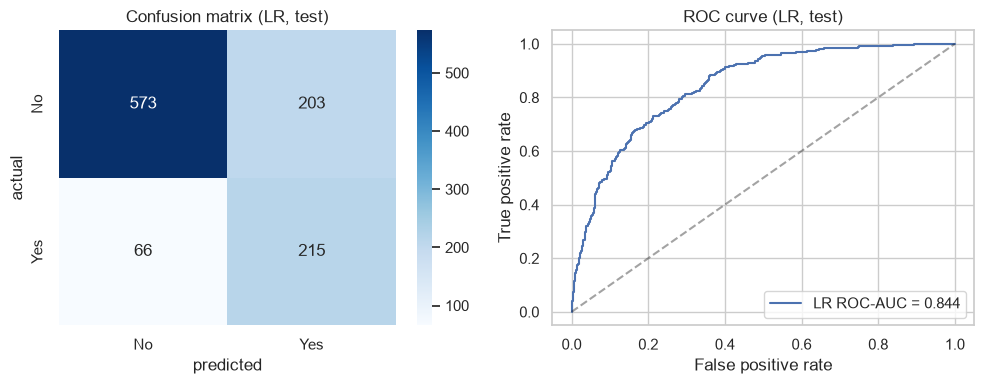

In [41]:
cm = confusion_matrix(y_test, yp)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])
ax[0].set_title('Confusion matrix (LR, test)')
ax[0].set_xlabel('predicted'); ax[0].set_ylabel('actual')

fpr, tpr, _ = roc_curve(y_test, yprob)
ax[1].plot(fpr, tpr, label=f'LR ROC-AUC = {roc_auc_score(y_test, yprob):.3f}')
ax[1].plot([0,1],[0,1], 'k--', alpha=0.4)
ax[1].set_title('ROC curve (LR, test)')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].legend()
plt.tight_layout(); plt.show()

## Step 28 — Model Interpretability

Logistic Regression hands us something trees can't: **coefficients**. Each coefficient says whether the factor pushes churn odds up or down. The picture matches the EDA exactly — the strongest churn drivers are month-to-month contracts, electronic-check payment and fiber internet; the strongest protectors are two-year contracts, automatic payment, and simply being around a long time.

The catch with LR coefficients is that they're log-odds on *scaled* numeric inputs (`tenure`, `MonthlyCharges`, ...) and one-hot 0/1 dummies. Because the numeric inputs were standardized during preprocessing, the coefficients are already "impact per 1 standard deviation (numeric) / per yes-vs-no (dummy)", so ranking them together on the same chart is fair.

One caution: `tenure` / `MonthlyCharges` / `TotalCharges` are collinear (TotalCharges VIF ≈ 9.5), so their individual coefficient signs wobble a bit under collinearity. Trust the categorical drivers (contract, internet service, payment method) for the directional story — those are clean — and the model's overall predictions.

In [42]:
lr_model = final_lr.named_steps['model']
feature_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_cols).tolist() + \
                preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

# LR was fit on standardized numerics + 0/1 dummies, so raw coefficients already mean
# "log-odds change per 1 std-dev (numeric) / per presence (dummy)" — directly comparable.
coefs = pd.Series(lr_model.coef_[0], index=feature_names)
scaled_coefs = coefs.sort_values()

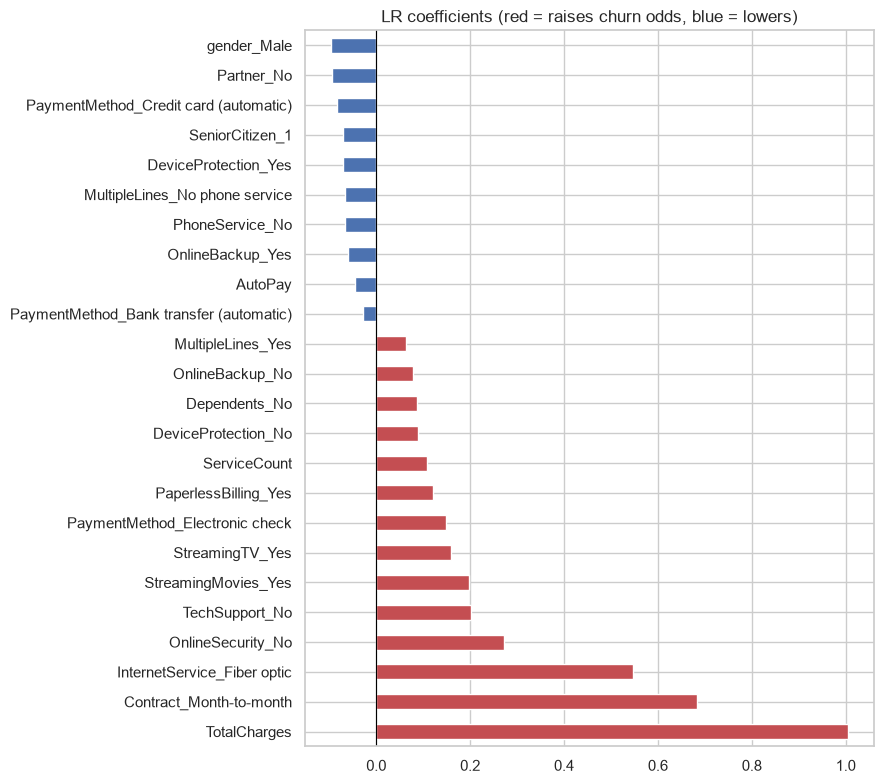

In [43]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#C44E52' if v > 0 else '#4C72B0' for v in scaled_coefs]
scaled_coefs.tail(24).plot(kind='barh', ax=ax, color=colors[-24:])
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)
ax.set_title('LR coefficients (red = raises churn odds, blue = lowers)')
plt.tight_layout(); plt.show()

In [44]:
print('Top 8 churn drivers  (LR coefficient):')
print(scaled_coefs.tail(8).round(3).to_string())
print('\nTop 8 churn protectors (LR coefficient):')
print(scaled_coefs.head(8).round(3).to_string())

Top 8 churn drivers  (LR coefficient):
PaymentMethod_Electronic check    0.149
StreamingTV_Yes                   0.160
StreamingMovies_Yes               0.197
TechSupport_No                    0.203
OnlineSecurity_No                 0.272
InternetService_Fiber optic       0.547
Contract_Month-to-month           0.684
TotalCharges                      1.005

Top 8 churn protectors (LR coefficient):
tenure                       -1.613
Contract_Two year            -0.747
MonthlyCharges               -0.566
InternetService_DSL          -0.530
PaperlessBilling_No          -0.322
Dependents_Yes               -0.288
OnlineSecurity_Yes           -0.255
PaymentMethod_Mailed check   -0.240


## Step 29 — Final Model Selection

**Chosen: tuned Logistic Regression** — test ROC-AUC **0.844**, F1 0.62, recall 0.77.

Why, given it's the "boring" model?
- It has the **best ROC-AUC of all six models on validation (0.8455) AND on 5-fold CV (0.8454)**, and the best CV F1 (0.6354).
- For a churn-retention program, **recall on the churn class matters more than raw accuracy** — LR catches ~77% of actual churners on the test set vs ~63-68% for the tree models.
- It's fast, tiny, and **every prediction can be explained coefficient-by-coefficient** to a business stakeholder. No 800 KB of tree ensembles when a linear decision boundary does as well.
- No overfitting: train vs test AUC gap is small (~0.85 vs 0.844).

Trade-offs, honestly stated: Gradient Boosting nudges ahead on accuracy (0.79 vs 0.75) and precision (0.59 vs 0.51), and a tuned XGBoost is a fine choice if you only care about precision. We traded ~4 accuracy points (0.78 vs 0.75) and ~6.5 precision points (0.58 vs 0.51) for ~9 recall points (0.77 vs 0.68) and full interpretability.

> Honest note: ROC-AUC 0.844 is solid but not jaw-dropping — churn comes from messy real-world forces (offers, competitors, personal circumstances) that a static account snapshot can only partially capture. Treat the model as a triage sieve: about 1 of every 2 flagged customers actually churns on the default 0.5 threshold, so a retention team should still qualify flagged customers (or raise the threshold) before spending an offer budget.

## Step 30 — Save & Version Model

Save the whole fitted pipeline (preprocessor + SMOTE + tuned Logistic Regression) so predictions reuse exactly the same preprocessing. This is the artifact you'd deploy behind a small API.

In [45]:
joblib.dump(final_lr, '../models/model_pipeline.pkl')
loaded = joblib.load('../models/model_pipeline.pkl')
check = loaded.predict_proba(X_test[:3])[:, 1]
print('saved + reloaded ok, sample churn probabilities:', np.round(check, 3))
print('model file size (KB):', round(__import__('os').path.getsize('../models/model_pipeline.pkl')/1024, 1))

saved + reloaded ok, sample churn probabilities: [0.66  0.188 0.065]
model file size (KB): 498.6


## Summary — what the analysis says

- **Who churns:** short-tenure customers on **month-to-month** contracts (89% of all churners), paying by **electronic check** (57% of churners), often on **fiber optic** internet without add-on services. 42.7% churn rate on month-to-month vs 2.8% on two-year contracts.
- **Best model:** tuned Logistic Regression → **test ROC-AUC 0.844**, F1 0.62, and it correctly flags **~77% of actual churners** at ~51% precision (about 1 in 2 flagged customers do churn).
- **Actionable:** score the existing base monthly, and target the top-decile-risk customers with a retention offer before renewal — starting with the month-to-month + electronic-check cluster, where expected lift is highest. Couple the model with a qualification step (offer size vs. customer lifetime value) before spending retention budget.

All raw data is in `data/`, the full executable analysis is this notebook, and the deployed artifact is `models/model_pipeline.pkl`.